# TOPIC!!!!

## Project Introduction



## Research Question

This project asks how selected Tibetan Buddhist bardo texts desrcribe the transition from dying to liberation or rebirth. My main research question is:

** How do seleted Tibetan Buddhist bardo texts connect dying, awareness, liberation, and rebirth? **

To answer this question, I use word frequency analysis and co-occurrence network analysis. First, I examine which words appear most frequently in the dataset. I pay special attention to words related to death and transition, such as "death," "dying," "bardo," "intermediate," and "becoming." I also look at words related to spritual possibility, such as "awareness," "mind," "clear light," "liberation," and "rebirth."

Second, I ask which of these words appear together in the same sections of the text. This helps me understand whether bardo is described mainly as a state after death, or as a process that connects dying with recognition, liberation, and rebirth. For example, if words such as "dying,""awareness," and "liberation" often appear together, this may suggest that the text present death as a moment when spiritual recognition is possible. If words such as "bardo," "becoming," and "rebirth" appear together, this may suggest that the texts also describe bardo as a transition toward another life.

This project does not try to prove a universal claim about all of Tibetan Buddhism. Instead, it focuses on a small dataset of selected bardo-related text. The goal is to use Python to identify patterns in the language of these texts, and then interpret those patterns through close reading. In this way, the project uses computational analysis as a starting point for understanding how bardo is represented as a space betwwen death, liberation, and rebirth.

## Data Source


## Load Dataset

In this section, I load the dataset for my project. The dataset is stored as a CSV file named `bardo_data.cvs`. Each row represents one section of a ztibetan Buddhist bardo-related text from Lostsawa House. The mean text for analysis is stored in the `text` column.

The dataset includes metadata such as source, URL, title, author, section, theme keyword, text type, summary, and notes. Loading the dataset with `pandas` allows me to inspect the structure of the data before beginning word frequency and co-occurence analysis.

In [2]:
import pandas as pd

dataframe = pd.read_csv('bardo_texts_dataset_Jun27.csv')

dataframe.head()



,title,section,id,source,url,author,keyword,text_type,text,summary,notes
0,The Root Verses on the Six Bardos,Bardo of This Life,T01_S01,Lotsawa House,https://www.lotsawahouse.org/tibetan-masters/k...,Karma Lingpa,bardo of this life,translated primary text,Kyema! Now when the bardo of this life is dawn...,The verse instructs the practitioner to use th...,Directly introduces the six-bardo framework ce...
1,The Root Verses on the Six Bardos,Bardo of Dreams,T01_S02,Lotsawa House,https://www.lotsawahouse.org/tibetan-masters/k...,Karma Lingpa,dream bardo,translated primary text,Kyema! Now when the bardo of dreams is dawning...,The dream bardo verse instructs the practition...,Dream recognition as parallel to bardo recogni...
2,The Root Verses on the Six Bardos,Bardo of Samādhi Meditation,T01_S03,Lotsawa House,https://www.lotsawahouse.org/tibetan-masters/k...,Karma Lingpa,samādhi bardo,translated primary text,Kyema! Now when the bardo of samādhi is dawnin...,The samādhi bardo verse calls for resting in n...,"Co-occurrence potential: 'samādhi,' 'delusion,..."
3,The Root Verses on the Six Bardos,Bardo of Dying,T01_S04,Lotsawa House,https://www.lotsawahouse.org/tibetan-masters/k...,Karma Lingpa,bardo of dying,translated primary text,Kyema! Now when the bardo of dying is dawning ...,The dying bardo verse instructs the practition...,Central section for the research question: cov...
4,The Root Verses on the Six Bardos,Bardo of Dharmatā,T01_S05,Lotsawa House,https://www.lotsawahouse.org/tibetan-masters/k...,Karma Lingpa,bardo of dharmatā,translated primary text,Kyema! Now when the bardo of dharmatā is dawni...,The dharmatā bardo verse instructs the practit...,"Directly addresses dharmatā appearances, recog..."


In [3]:
dataframe.shape

(86, 11)

In [12]:
dataframe.columns

Index(['title', 'section', 'id', 'source', 'url', 'author', 'keyword',
       'text_type', 'text', 'summary', 'notes', 'cleaned_text'],
      dtype='str')

In [13]:
print("Dataset loaded successfully!")
print("Total sections:", len(dataframe))
print("Total unique texts:", dataframe['title'].nunique())
print("Total unique authors:", dataframe['author'].nunique())

Dataset loaded successfully!
Total sections: 86
Total unique texts: 20
Total unique authors: 14


## Word Frequency Analysis

### Word Frequency

In [58]:
import re
from collections import Counter

def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'[^\w\s]', ' ', text)  # Remove punctuation with one space
    text = re.sub(r'\s+', ' ', text)  # Replace extra spaces with one space
    return text

# Apply the cleaning function to the 'text' column
dataframe['cleaned_text'] = dataframe['text'].apply(clean_text)

dataframe[["id", "keyword", "text", "cleaned_text"]].head()


# Create a stopword list

stopwords = set([  "the", "and", "of", "to", "in", "a", "is", "that", "it", "for",
                   "as", "with", "on", "by", "this", "be", "are", "from", "or",
                    "an", "at", "which", "into", "will", "can", "all", "their",
                    "these", "those", "then", "than", "there", "here", "such",
                    "also", "when", "where", "who", "what", "how", "if", "but",
                    "not", "so", "do", "does", "did", "has", "have", "had",
                    "was", "were", "been", "being", "they", "them", "he", "she",
                    "his", "her", "its", "we", "you", "your", "i", "my", "me",
                    "our", "us", "one", "ones", "own", "therefore", "thus",
                    "may", "should", "would", "could", "shall", "upon", "without", 
                    "now", "yet", "ever", "never", "always", "sometimes", "often", 
                    "usually", "like", "just", "even", "more", "most", "many", 
                    "some", "few", "several", "within", "between", "among", "about", 
                    "above", "below", "under", "during", "before", "after", "since", 
                    "until", "while", "although", "two", "three", "four", "five", 
                    "six", "seven", "eight", "nine", "ten", "through", "over", 
                    "across", "along", "toward", "towards", "away", "back"])

In [63]:
all_text = " ".join(dataframe["cleaned_text"])

words = all_text.split()

filtered_words = [word for word in words if word not in stopwords]

word_counts = Counter(filtered_words)

word_counts.most_common(60)

[('death', 46),
 ('mind', 44),
 ('bardo', 39),
 ('dissolves', 35),
 ('body', 32),
 ('pure', 29),
 ('time', 28),
 ('clear', 27),
 ('light', 25),
 ('awareness', 24),
 ('s', 24),
 ('life', 22),
 ('perception', 22),
 ('wisdom', 20),
 ('luminosity', 19),
 ('state', 17),
 ('experience', 17),
 ('sign', 17),
 ('space', 16),
 ('inner', 16),
 ('consciousness', 16),
 ('water', 15),
 ('wind', 15),
 ('appearances', 15),
 ('ground', 15),
 ('first', 15),
 ('element', 15),
 ('arise', 14),
 ('appearance', 14),
 ('natural', 13),
 ('dharmatā', 13),
 ('moment', 13),
 ('great', 13),
 ('nature', 13),
 ('subtle', 13),
 ('heart', 13),
 ('cultivate', 13),
 ('no', 12),
 ('earth', 12),
 ('beings', 12),
 ('form', 12),
 ('amitābha', 12),
 ('path', 11),
 ('meditation', 11),
 ('single', 11),
 ('dharmakāya', 11),
 ('dissolve', 11),
 ('dissolution', 11),
 ('birth', 11),
 ('any', 11),
 ('elements', 10),
 ('fire', 10),
 ('instant', 10),
 ('sky', 10),
 ('arises', 10),
 ('outer', 10),
 ('instructions', 9),
 ('take', 9),
 

In [64]:
word_freq_df = pd.DataFrame(word_counts.items(), 
                            columns = ["word", "count"])

word_freq_df = word_freq_df.sort_values(by='count', ascending=False)


This table above shows the most common meaningful words after removing common stop words. This gives a general overview of the language in the dataset. However, this table alone is limited because the most frequenct words are not always the most important concepts. For this reason, I also group keywords into thematic categories related to my research question.

### Thematic Frequency Analysis ###

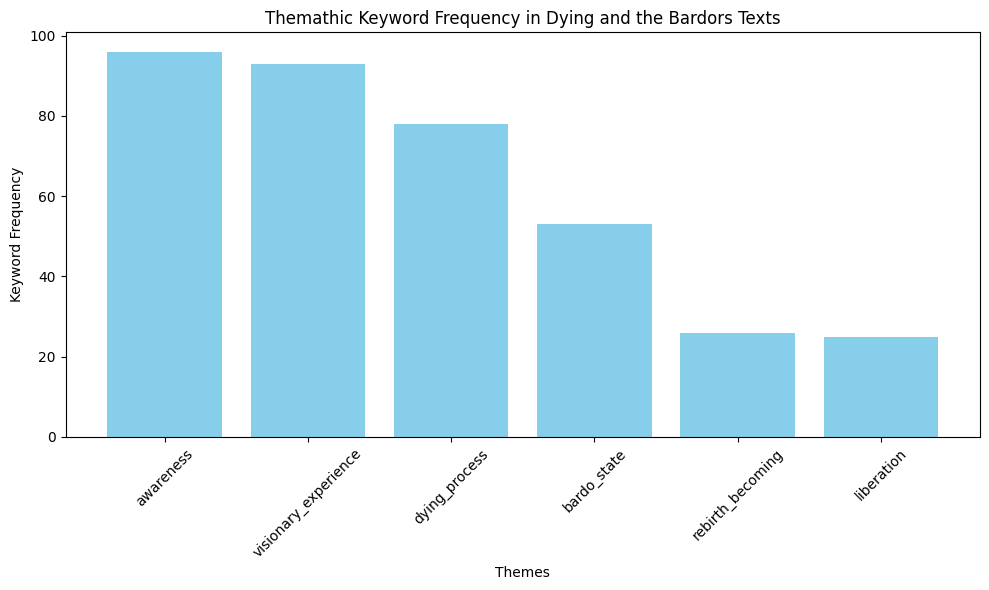

In [65]:
def count_keyword(text, term):
    text = text.lower()
    term = term.lower()
    pattern = r'\b' + re.escape(term) + r'\b'
    return len(re.findall(pattern, text))

theme_keywords = {"dying_process":
                    ["death", "dying", "deceased", "die", "dissolution"],
                  "bardo_state":
                     ["bardo", "bardos", "intermediate", "transitional", "between"],
                  "awareness":
                     ["awareness", "consciousness", "mind", "rigpa", "recognition", "recognize"],
                  "liberation":
                     ["liberation", "liberated", "awakening", "enlightenment", "realization", "realize"],
                  "rebirth_becoming":
                     ["rebirth", "birth", "becoming", "samsara", "samsaric"],
                  "visionary_experience":
                     ["vision", "visions", "experience", "experiences", "appearance", "appearances", "clear light", "sound", "deity", "deities", "peaceful", "wrathful"]}

thematic_freq_results = []

for theme, keywords in theme_keywords.items():
    total_count = 0
        
    for keyword in keywords:
        keyword_count = dataframe["cleaned_text"].apply(lambda text: count_keyword(text, keyword)).sum()

        total_count += keyword_count

        thematic_freq_results.append({"theme": theme,
                              "keyword": keyword,
                              "count": keyword_count})    

theme_freq_df = pd.DataFrame(thematic_freq_results)
theme_freq_df.sort_values(by = "count", ascending = False).head(30)

theme_summary_df = (theme_freq_df
                    .groupby("theme")["count"]
                    .sum()
                    .reset_index()
                    .sort_values(by = "count", ascending = False))


plt.figure(figsize=(10, 6))

plt.bar(theme_summary_df["theme"], 
        theme_summary_df["count"], 
        color='skyblue')

plt.xticks(rotation=45)
plt.xlabel("Themes")
plt.ylabel("Keyword Frequency")
plt.title("Themathic Keyword Frequency in Dying and the Bardors Texts")

plt.tight_layout()
plt.show()

explanation

### Normalize Frequency ###

In [66]:
code

NameError: name 'code' is not defined

explanation

### Keyword in Context ###

In [ ]:
code

explanation

summary

## Keyword Frequency Bar Chart

In [ ]:
import re

selected_keywords = [ "bardo", "bardos",
                     "death", "dying", "dead", "deceased",
                     "liberation", "liberated",
                     "rebirth", "becoming",
                     "awareness", "mind", "consciousness", "rigpa",
                     "clear light",
                     "appearance", "appearances",
                     "peaceful", "wrathful"]

def keyword_in_text(text, keyword):
    pattern = "\b" + re.escape(keyword) + r"\b"
    return len(re.findall(pattern, text))

selected_keywords_count = []

for keyword in selected_keywords:
    count = dataframe["cleaned_text"].apply(lambda text: keyword_in_text(text, keyword)).sum()
    selected_keywords_count.append({"keyword": keyword, "count": count})
    
    

## Co-occurrence Network Analysis

## Network Visualization

## Reflection